## 1.8 Kuantum One-Time Pad (The (quantum) one-time pad)

Mesajları şifrelemek için kullanılabilecek, dünyadaki belki de en basit ve en güçlü şemayı ele alalım. Bu sistem literatürde **one-time pad (tek kullanımlık şerit)** olarak bilinir ve mükemmel bir güvenlik sunar. 

### 1.8.1 Klasik One-Time Pad (The classical one-time pad)

Gönderici konumundaki Alice'in, alıcı konumundaki Bob'a $n$-bit uzunluğunda gizli bir $m \in \{0,1\}^n$ mesajı göndermek istediğini hayal edelim. Ayrıca, Alice ve Bob'un daha önceden kendi aralarında paylaştıkları, tam olarak mesajla aynı uzunlukta ($n$-bit) gizli bir $k \in \{0,1\}^n$ anahtarına sahip olduklarını varsayalım. Hatırlayacağınız üzere, rastgele mesajlar için mutlak güvenliği sağlamanın ilk şartı anahtarın en az mesaj kadar uzun olmasıydı.

> 🟦 **Protokol 1 — Klasik One-Time Pad.** Klasik bir tek kullanımlık şerit algoritmasında, $k \in \{0,1\}^n$ anahtarı kullanılarak bir $m \in \{0,1\}^n$ mesajının şifrelenmesi ($\text{Enc}$) bit düzeyinde şu şekilde gerçekleştirilir:
> 
> $$\text{Enc}(k,m) = m \oplus k = (m_1 \oplus k_1, m_2 \oplus k_2, \dots, m_n \oplus k_n) = (e_1, \dots, e_n) = e \quad \text{--- (1.66)}$$
> 
> Burada $m_j \oplus k_j = m_j + k_j \pmod 2$ işlemi, bilişim dünyasından aşina olduğumuz **XOR (özel veya)** ya da modülo 2 tabanında toplama işlemidir. Şifreli mesajın deşifre edilmesi ($\text{Dec}$) ise Bob tarafında yine aynı anahtarla XOR işlemi uygulanarak çözülür:
> 
> $$\text{Dec}(k,e) = e \oplus k = (e_1 \oplus k_1, e_2 \oplus k_2, \dots, e_n \oplus k_n) \quad \text{--- (1.67)}$$

Kriptografide $m_j \oplus k_j \oplus k_j = m_j$ özdeşliği her zaman sağlandığından, dürüst alıcı Bob orijinal mesajı hiçbir veri kaybı olmadan hatasız bir şekilde geri elde edebilir; bu da şemanın **doğruluk (correctness)** şartını tam olarak sağladığını gösterir.


Bunun Shannon'ın mükemmel gizlilik tanımına uyup uymadığını görmek için herhangi bir sabit $m$ mesajını ele alalım. Eğer $k$ anahtarı evrensel olarak tamamen rastgele (uniformly random) seçiliyorsa, üretilen $e = \text{Enc}(k,m)$ şifreli metni de olası tüm $n$-bitlik dizgeler üzerinde tamamen homojen ve rastgele dağılır. Belirli bir $m$ mesajı verildiğinde, kanaldan spesifik bir $e$ dizesinin geçme koşullu olasılığı şu şekildedir:

$$p(e \mid m) = p(m \oplus k \mid m) = p(k \mid m) = \frac{1}{2^n} \quad \text{--- (1.68)}$$

Çünkü $k = e \oplus m$ şartını sağlayan tam olarak tek bir benzersiz anahtar mevcuttur. Bu eşitliğin tüm olası $m$ mesajları için geçerli olduğunu göz önünde bulundurursak, toplam olasılık teoremi yardımıyla kanaldan genel olarak bir $e$ şifreli metninin geçme marjinal olasılığını ($p(e)$) şu şekilde bulabiliriz:

$$p(e) = \sum_{m} p(m) p(e \mid m) = \frac{1}{2^n} \sum_{m} p(m) = \frac{1}{2^n} \quad \text{--- (1.69)}$$

Şimdi elde ettiğimiz bu değerleri Bayes kuralında yerine koyarak casusun gözünden olasılık durumunu analiz edelim:

$$p(m \mid e) = \frac{p(m,e)}{p(e)} = \frac{p(e \mid m)p(m)}{p(e)} = \frac{(1/2^n) \cdot p(m)}{1/2^n} = p(m) \quad \text{--- (1.70)}$$

Görüldüğü üzere, şifreli metin $e$ ne olursa olsun, mesajın sonrasal olasılığı önsel olasılığına kuruşu kuruşuna eşit çıkmaktadır ($p(m \mid e) = p(m)$). Bu matematiksel sonuç, şemanın **mükemmel güvenli** olduğunu tartışmasız bir şekilde ispatlar!


⚠️ **Çok Kritik Bir Güvenlik Uyarısı:** Yukarıdaki mükemmel gizlilik ispatı, tamamen anahtarın **kusursuz bir şekilde rastgele dağıldığı ve casus Eve'den tamamen bağımsız olduğu** varsayımına dayanır. Gerçek hayatta bu varsayımı klasik cihazlarla yakalamak aşırı derecede zordur ve çok büyük dikkat gerektirir. 

Eğer anahtar rastgele üretilmezse veya casus anahtar hakkında en ufak bir sızıntı bilgisine (kısmi bilgiye) sahip olursa, tüm mükemmel gizlilik koruması anında çöker! 

İşte bu Bölüm04 de, bir saldırganın elinde anahtara dair kısmi/hatalı bilgiler olduğunda, o anahtarın kalitesini kuantum mekaniksel yöntemlerle yeniden kusursuz hale getiren **Gizlilik Güçlendirmesi (Privacy Amplification)** protokollerini öğreneceğiz. Kuantum bilginin klasik şifrelemeye getirdiği o devrimsel çözümleri ilerleyen bölümlerde adım adım gösterelim!


In [1]:
import numpy as np

# Örnek olarak n = 4 bitlik bir sistem ele alalım
n = 4

# Alice'in mesajı sabit olsun (m =)
m = np.array([1, 0, 1, 0])

# İspat doğrulaması: Kanaldan e = [1, 1, 1, 1] geçmesini istiyoruz (Sabit bir e)
e_hedef = np.array([1, 1, 1, 1])

# Formül 1.68'e göre bu e'yi üretebilecek tek bir k anahtarı olmalıdır (k = e ^ m)
k_gerekli = np.bitwise_xor(e_hedef, m)
print(f"Hedeflenen e şifreli metnini üretebilecek tek gizli anahtar (k): {k_gerekli}")

# Olasılık kontrolü: 4 bitlik uzayda toplam 2^4 = 16 olası anahtar vardır.
# Bu anahtarlar içinden sadece 1 tanesi hedef e'yi verebildiği için p(e|m) = 1 / 2^n olur.
p_e_given_m = 1 / (2**n)
print(f"Matematiksel p(e|m) Olasılığı: {p_e_given_m} (Yani 1/{2**n})")


Hedeflenen e şifreli metnini üretebilecek tek gizli anahtar (k): [0 1 0 1]
Matematiksel p(e|m) Olasılığı: 0.0625 (Yani 1/16)


One-Time Pad protokolünün mükemmel bir gizlilik sunduğunu ispatlamış olsak da, çok kritik bir zafiyeti olduğunu not etmek gerekir: Bu sistem, casus Eve'in kanaldan geçen mesajın bitlerini değiştirmesine (**bütünlük/integrity ihlaline**) karşı hiçbir koruma sağlamaz! 

Örneğin, Eve kanaldan geçen şifreli metindeki belirli bitleri tersine çevirebilir (bit-flip saldırısı). Siz bir resim dosyası gönderirken bazı bitlerin değişmesi görüntüyü çok fazla bozmayabilir; ancak banka işlemleriniz sırasında transfer edilen para miktarını temsil eden bitlerin yerinin değiştirilmesi çok büyük bir felakete yol açacaktır! 

Tam da bu nedenle, gerçek hayatta tek kullanımlık şerit uygulamaları, verideki değişikliklerin dürüst alıcı tarafından anında tespit edilmesini (ve düzeltilmesini) sağlayan **sağlama toplamları (checksums)** veya **mesaj doğrulama kodları (MAC - Message Authentication Codes)** ile desteklenir. Bunlar tamamen klasik kriptografi teknikleri olduğu için bu ders notlarında detaylarına değinmeyeceğiz.


Klasik tek kullanımlık şeride, bizi bir sonraki adımda göreceğimiz kuantum versiyonuna çok daha fazla yaklaştıracak tamamen farklı bir pencereden bakmanın bir yolu daha vardır. 

Bu yaklaşımı daha iyi anlamak adına, tek bir bitlik gizli bir $m \in \{0, 1\}$ mesajının şifrelenmesini ele alalım. Ders notlarımızın önceki kısımlarından hatırlayacağınız üzere, bu klasik mesajı kuantum dünyasında bir $|m\rangle$ ket vektörü veya bir $|m\rangle\langle m|$ yoğunluk matrisi olarak kodlayabiliriz (kodlama adımı). 

Klasik XOR işlemini bu kuantum durumuna uyguladığımızda karşımıza çıkan mekanik şöyledir: Eğer seçilen anahtar biti $k = 1$ ise, orijinal $m$ biti tersine döner. Bunun kuantum operatör dünyasındaki tam karşılığı, duruma bir Pauli-X (NOT) kapısı uygulamaktır; yani durumimiz **$X|m\rangle$** vektörüne veya yoğunluk matrisi dilinde **$X|m\rangle\langle m|X$** matrisine dönüşür! (Eğer $k=0$ ise durum $X^0 = \mathbb{I}$ olduğundan olduğu gibi kalır).


Alice ve Bob'un bu şifreleme işlemi için tamamen rastgele ve eşit olasılıklı bir $k$ anahtarı ($p(k)=1/2$) seçtiğini varsayalım. Bu durumda, anahtara erişimi olmayan casus Eve'in iletişim kanalına baktığında göreceği nihai kuantum durumu, olası tüm anahtar operasyonlarının istatistiksel bir karışımı (yoğunluk matrisi) olacaktır:

$$\rho = \frac{1}{2} \sum_{k \in \{0,1\}} X^k \rho_m X^k = \frac{1}{2}|m\rangle\langle m| + \frac{1}{2}X|m\rangle\langle m|X = \frac{\mathbb{I}}{2} \quad \text{--- (1.71)}$$

Buradaki $\mathbb{I}/2$ ifadesi, daha önce de sıkça karşılaştığımız maksimum karma durum matrisidir:

$$\frac{\mathbb{I}}{2} = \begin{pmatrix} 1/2 & 0 \\ 0 & 1/2 \end{pmatrix} \quad \text{--- (1.72)}$$


Elde ettiğimiz bu nihai $\rho$ yoğunluk matrisinin en muazzam ve can alıcı özelliği, orijinal **$m$ mesajından tamamen bağımsız olmasıdır!** 

Yani Alice mesaj olarak ister "0" göndermiş olsun, ister "1" göndermiş olsun; casus Eve'in kanalda gördüğü matris kuruşu kuruşuna her zaman tamamen aynı $\mathbb{I}/2$ matrisi çıkmaktadır. Dolayısıyla, sistemin kuantum yoğunluk matrisinden orijinal mesajın içeriğine dair **kesinlikle hiçbir bilgi edinilemez**; mesaj ile casusun elindeki veriler arasındaki ilişki (korelasyon) tam olarak sıfırdır. 

Bu "ilişkisizlik" durumu, kuantum bilgi teorisinde aradığımız mutlak ve kusursuz güvenlik standardının ta kendisidir. İlerleyen haftalarda bu kuantum matris mekanizmasını çok daha büyük şifreleme sistemlerine nasıl genişleteceğimizi adım adım inşa edeceğiz!


In [2]:
import numpy as np

# Pauli-X (NOT) matrisini tanımlayalım
X = np.array([[0, 1], 
              [1, 0]])

# Alice'in rastgele bir mesaj gönderdiğini varsayalım (Örn: m = 1 durumu)
# |1><1| yoğunluk matrisi
rho_m = np.array([[0, 0], 
                  [0, 1]])

# Formül 1.71'e göre casusun gördüğü nihai karma matrisi (rho) hesaplayalım
# k=0 için: 0.5 * I * rho_m * I = 0.5 * rho_m
# k=1 için: 0.5 * X * rho_m * X
rho_eve = (0.5 * rho_m) + (0.5 * np.linalg.multi_dot([X, rho_m, X]))

print("Casus Eve'in kanalda gözlemlediği nihai kuantum yoğunluk matrisi:\n", rho_eve)
print("\nTeorik maksimum karma durum matrisi (I/2):\n", np.eye(2) / 2)
print(f"\nİspat Doğrulandı mı? (Matrisler eşit mi?): {np.allclose(rho_eve, np.eye(2)/2)}")


Casus Eve'in kanalda gözlemlediği nihai kuantum yoğunluk matrisi:
 [[0.5 0. ]
 [0.  0.5]]

Teorik maksimum karma durum matrisi (I/2):
 [[0.5 0. ]
 [0.  0.5]]

İspat Doğrulandı mı? (Matrisler eşit mi?): True


### 1.8.2 Kuantum One-Time Pad (The quantum one-time pad)

Klasik bir bit yerine, doğrudan bir kuantum bitini (kübit) şifreleme görevini ele alalım [Amb+00; BR00]. Bir qubit'i şifrelerken, klasik durumun aksine tek bir gizli anahtar biti yeterli olmaz; doğrulanabilir bir güvenlik için **iki adet gizli anahtar bitine ($k_1, k_2$)** ihtiyacımız vardır.

Bunun temel sezgisel nedeni, kübit'in içinde bulunabileceği tüm olası tabanlardaki (bazlardaki) bilgiyi casustan tamamen gizlemek istememizdir. Klasik şifrelemede sadece standart taban doğrultusunda bir $X$ (bit-flip) operatörü uygulamak yeterliydi. Ancak sistemi sadece $X$ kapısıyla şifreleyip Hadamard tabanında ($|+\rangle, |-\rangle$) bir kübit göndermeye çalışırsak; $X|+\rangle\langle+|X = |+\rangle\langle+|$ ve $X|-\rangle\langle-|X = |-\rangle\langle-|$ olduğundan, kuantum durumu şifreleme prosedüründen **hiçbir şekilde etkilenmeden aynen kalır**. Bu da sistemin tamamen güvensiz olması demektir.

Bir kuantum tek kullanımlık şeridinin (Quantum One-Time Pad) asıl sırrı, hem standart hesapsal tabanda hem de Hadamard tabanında aynı anda bir çevirme işlemi uygulamaktır. Bu durum, sisteme ardışık olarak **$X^{k_1} Z^{k_2}$** kapılarını uygulayarak elde edilir. Eğer $k_1 k_2$ anahtar bitleri tamamen rastgele ve eşit olasılıkla ($1/4$) seçilirse, rastgele bir tek-qubitlik $\rho$ yoğunluk matrisi şu şekilde şifrelenir:

$$\rho_{\text{şifreli}} = \frac{1}{4} \sum_{k_1, k_2 \in \{0,1\}} X^{k_1} Z^{k_2} \rho \, Z^{k_2} X^{k_1} \quad \text{--- (1.72)}$$


Bu mekanizmanın neden kusursuz çalıştığını ve casus Eve'in elindeki tüm yönlü bilgileri nasıl sıfırladığını görmek adına, Pauli matrislerinin ikili olarak **anti-komüte (anti-commute)** etme özelliklerini hatırlayalım. Pauli matrisleri birer gözlemlenebilirdir (Hermityen'dir ve kareleri birim matrisi verir: $X^2 = Z^2 = \mathbb{I}$). Ayrıca farklı Pauli matrisleri için $\{X,Z\} = XZ + ZX = 0 \implies XZ = -ZX$ ilişkisi geçerlidir.

Şimdi, (1.72) numaralı genel toplamın içindeki tüm olasılık kombinasyonlarının $X$ matrisi üzerindeki doğrusal etkisini (1.73) zinciri üzerinden adım adım açalım:

$$X + XXX + ZXZ + XZXZX = 0 \quad \text{--- (1.73)}$$

Bu sadeleşmenin nasıl sıfıra ($0$) çıktığını basamak basamak ispatlayalım:
1. **$X$**: İlk terim doğrudan kalır.
2. **$XXX$**: $X^2 = \mathbb{I}$ olduğundan, $XXX = (\mathbb{I})X = X$ olur.
3. **$ZXZ$**: Anti-komütasyon kuralıyla $X$ ve $Z$'nin yerini değiştirelim: $Z(XZ) = Z(-ZX) = -Z^2X = -X$ olur.
4. **$XZXZX$**: Ortadaki blokları aşama aşama sadeleştirelim: $X(ZXZ)X = X(-X)X = -X^2X = -X$ olur.

Tüm bu terimleri yan yana toplayıp birleştirdiğimizde:
$$X + X - X - X = 0$$

sonucuna ulaşırız. Rastgele seçilen $k_1 k_2$ anahtarlarının yarattığı bu simetrik etkiler kuantum uzayında birbirini kusursuzca yok eder. Bu durum, orijinal $\rho$ matrisinin içindeki tüm verilerin silinerek sistemin neden tamamen homojen bir $\mathbb{I}/2$ matrisine dönüştüğünün kesin kanıtıdır. Bloch küresi üzerindeki bu geometrik dağılımı canlandıran Figür 1.1 şemasına göz atabilirsiniz.


> 🟦 **Alıştırma 1.8.1 — Kuantum One-Time Pad Genel İspatı.** Herhangi bir $M \in \{X, Z, Y\}$ Pauli matrisi için aşağıdaki genel ifadenin tam olarak sıfıra eşit olduğunu gösteriniz:
> 
> $$\frac{1}{4} \sum_{k_1, k_2 \in \{0,1\}} X^{k_1} Z^{k_2} M \, Z^{k_2} X^{k_1} = 0 \quad \text{--- (1.74)}$$

**İspat:**
Bu toplamın içindeki 4 olası anahtar kombinasyonunu ($k_1k_2 \in \{00, 01, 10, 11\}$) açıkça yazarak doğrusal terimleri yan yana getirelim. $X^0 = Z^0 = \mathbb{I}$ olduğunu biliyoruz. O halde toplamın açık hali şu şekildedir:
$$\text{Toplam} = \frac{1}{4} \Big( M + ZMZ + XMX + XZMZX \Big)$$

Şimdi bu ifadenin her bir Pauli matrisi ($X, Z, Y$) için nasıl sıfıra çıktığını tek tek gösterelim:

1. **$M = X$ Durumu İçin:**
   *   $ZXZ = -X$ (Anti-komütasyon: $ZX = -XZ$ ve $Z^2 = \mathbb{I}$ olduğundan)
   *   $XXX = X$ ($X^2 = \mathbb{I}$ olduğundan)
   *   $XZXZX = X(ZXZ)X = X(-X)X = -X^2X = -X$
   *   *Yerine Koyalım:* $\frac{1}{4}\big( X - X + X - X \big) = \frac{1}{4}(0) = 0$.

2. **$M = Z$ Durumu İçin:**
   *   $ZZZ = Z$ ($Z^2 = \mathbb{I}$ olduğundan)
   *   $XZX = -Z$ (Anti-komütasyon: $XZ = -ZX$ ve $X^2 = \mathbb{I}$ olduğundan)
   *   $XZZZX = X(Z)X = XZX = -Z$
   *   *Yerine Koyalım:* $\frac{1}{4}\big( Z + Z - Z - Z \big) = \frac{1}{4}(0) = 0$.

3. **$M = Y$ Durumu İçin:**
   Pauli-Y matrisi hem X hem de Z matrisleri ile anti-komüte eder ($\{X,Y\}=0$ ve $\{Z,Y\}=0$).
   *   $ZYZ = Z(-ZY) = -Z^2Y = -Y$
   *   $XYX = X(-XY) = -X^2Y = -Y$
   *   $XZYZX = XZ(-YZ)X = X(ZY)X = X(-YZ)X = -XZYX = -X(-XY) = X^2Y = Y$
   *   *Yerine Koyalım:* $\frac{1}{4}\big( Y - Y - Y + Y \big) = \frac{1}{4}(0) = 0$.

Üç temel doğrusal operatör için de toplam tam olarak sıfır çıktığından genel ispat başarıyla tamamlanmıştır.


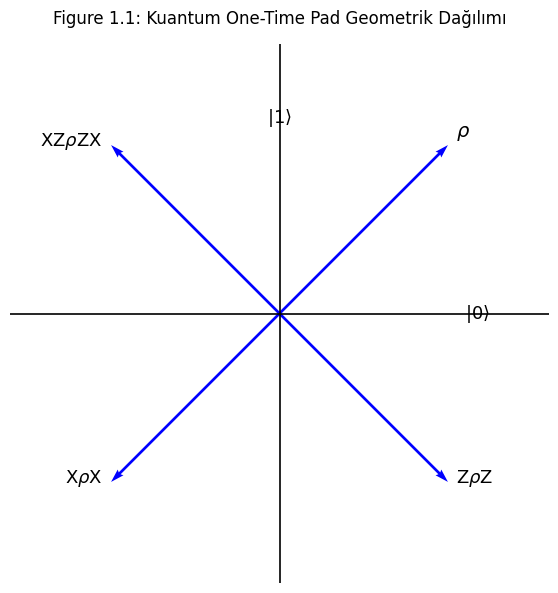

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Çizim alanı ve çözünürlük ayarları
fig, ax = plt.subplots(figsize=(7, 7), dpi=100)

# Eksen Çizgilerini Oluşturma (Merkezde kesişen X ve Y eksenleri)
ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

# Vektörlerin uç nokta koordinatlarını belirleme (Simetrik 4 köşe)
# Orijinal ok yönlerini yakalamak için işaret yönleri ayarlanmıştır
v_rho = [1, 1]
v_xz = [-1, 1]
v_x = [-1, -1]
v_z = [1, -1]

# Vektörleri çizdirme (Mavi oklar)
# quiver(başlangıç_x, başlangıç_y, doğrultu_x, doğrultu_y)
ax.quiver(0, 0, v_rho[0], v_rho[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005)
ax.quiver(0, 0, v_xz[0], v_xz[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005)
ax.quiver(0, 0, v_x[0], v_x[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005)
ax.quiver(0, 0, v_z[0], v_z[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005)

# Metinleri ve Etiketleri Yerleştirme (Görseldeki yerleşim düzenine birebir sadık kalınarak)
# LaTeX biçiminde rho (\rho) sembolü kullanılmıştır
ax.text(1.1, 0, r"$|0\rangle$", fontsize=13, verticalalignment='center', horizontalalignment='left')
ax.text(0, 1.1, r"$|1\rangle$", fontsize=13, verticalalignment='bottom', horizontalalignment='center')

# Ok uçlarının yanındaki matematiksel ifadeler
ax.text(v_rho[0] + 0.05, v_rho[1] + 0.05, r"$\rho$", fontsize=14, color='black')
ax.text(v_xz[0] - 0.05, v_xz[1], r"$\mathrm{XZ}\rho\mathrm{ZX}$", fontsize=13, color='black', horizontalalignment='right')
ax.text(v_x[0] - 0.05, v_x[1], r"$\mathrm{X}\rho\mathrm{X}$", fontsize=13, color='black', horizontalalignment='right')
ax.text(v_z[0] + 0.05, v_z[1], r"$\mathrm{Z}\rho\mathrm{Z}$", fontsize=13, color='black', horizontalalignment='left')

# Kılavuz çizgileri ve eksen sınırlarının optimizasyonu
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)

# Kare oranını koruma (Daire/küre izdüşümünün düzgün görünmesi için şarttır)
ax.set_aspect('equal')

# Arka plandaki sayısal kılavuz çizgilerini kapatma (Sadece temiz bir eksen kalması için)
ax.axis('off')

# Başlık ekleme
plt.title("Figure 1.1: Kuantum One-Time Pad Geometrik Dağılımı", fontsize=12, pad=15)
plt.show()


### Şekil 1.1 — İki Anahtar Biti İle Qubit Şifreleme (Figure 1.1)

Yukarıda matematiksel olarak yaptığımız bu iptallerin geometrik karşılığı Şekil 1.1'de tasvir edilmiştir. Herhangi bir başlangıç $\rho$ durum vektörünü ele alalım. Kuantum One-Time Pad protokolünde sisteme eşit olasılıklarla uygulanan $\mathbb{I}, X, Z, XZ$ işlemleri, Bloch uzayındaki durum vektörünü küre merkezine göre tamamen zıt ve simetrik 4 farklı köşeye doğru fırlatır. 

Bu 4 simetrik durumun istatistiksel olarak eşit ağırlıklı karışımı (karma durumu) alındığında, vektörlerin birbirini dengelenmesi sonucunda sistem tam olarak **koordinat sisteminin merkezine (orijine)** çöker. Bloch küresinin orijini (merkezi) ise fiziksel olarak tam bir belirsizliği, yani hiçbir yön bilgisi barındırmayan maksimum karma durumu ifade eder.


> 🟦 **Protokol 2 — Kuantum One-Time Pad ($n$-kübit genişletmesi).** Kuantum tek kullanımlık şerit (qOTP), kübit durumlarını şifrelemek için tasarlanmış doğrusal bir şemadır. Tek bir kübit durumunu ($\rho$) şifrelemek için Alice, sisteme rastgele seçtiği anahtar bitlerine göre $X^{k_1} Z^{k_2}$ kapılarını uygular ve oluşan şifreli durumu Bob'u iletir. Bob ise şifreyi çözmek (deşifre etmek) için bu işlemin tersini, yani $(X^{k_1} Z^{k_2})^\dagger = Z^{k_2} X^{k_1}$ operatörünü uygulayarak orijinal $\rho$ durumunu kayıpsız bir şekilde geri elde eder.

Bu şema, ardışık olarak $n$ adet kübit barındıran büyük sistemlere doğrudan genişletilebilir. Çoklu sistemde her bir kübit üzerine iki anahtar bitine bağlı olacak şekilde $\mathbb{I}, X, Z$ veya $XZ$ işlemlerinden biri uygulanır. Bu durum, $n$ uzunluğundaki bir kuantum durum uzayını tamamen şifreleyebilmek için toplamda **$2n$ bit uzunluğunda klasik bir gizli anahtar** kullanmamız gerektiği anlamına gelir.


> 🟦 **Alıştırma 1.8.2** $s \in \{0,1\}^{2n}$ bir ikili dizgeyi temsil etmek üzere; $P^s = X^{s_1} Z^{s_2} \otimes X^{s_3} Z^{s_4} \otimes \dots \otimes X^{s_{2n-1}} Z^{s_{2n}}$ şeklinde tanımlanan Pauli matris dizilerinin, $\mathcal{L}(\mathbb{C}^{2^n}, \mathbb{C}^{2^n})$ doğrusal operatörler uzayı için bir **ortogonal taban (orthogonal basis)** oluşturduğunu gösteriniz. Buradan yola çıkarak, $s \neq \hat{s}$ olduğu her durum için **$\text{tr}\big((P^s)^\dagger P^{\hat{s}}\big) = 0$** olduğunu ispatlayınız ve herhangi bir $n$-qubitlik $\rho$ yoğunluk matrisinin bu taban cinsinden şu şekilde parametrize edilebileceğini doğrulayınız:
> 
> $$\rho = \frac{1}{2^n} \left( \mathbb{I}^{\otimes 2n} + \sum_{s \neq 0} v_s P^s \right) \quad \text{--- (1.77)}$$

**İspat İpucu:**
Tensör çarpımının iz (trace) işlemi üzerindeki dağılma özelliğini hatırlayalım: $\text{tr}(A \otimes B) = \text{tr}(A) \cdot \text{tr}(B)$. İki farklı Pauli dizisinin iç çarpımını aldığımızda, en az bir koordinatta farklı Pauli matrislerinin çarpımı (örneğin $\text{tr}(X^\dagger Z)$ veya $\text{tr}(X^\dagger \mathbb{I})$) çarpan olarak gelecektir. Bölüm01 notlarında tekil Pauli matrislerinin Hilbert-Schmidt iç çarpımı altında birbirine dik olduğunu ($\text{tr}=0$) zaten göstermiştik. Çarpanlardan biri sıfır ($0$) olduğunda, tüm tensör çarpımının izi de anında sıfıra çökecektir. Bu durum matris dizilerinin ortogonal olduğunu kesin olarak kanıtlar.


💡 **Önemli Bir Teorik Analiz:**
Tek kübitlik sistemlerde (1-qubit), $\rho$ yoğunluk matrisinin başındaki $v_s$ katsayılarının ($v_x, v_y, v_z$) geometrik olarak 3 boyutlu bir Bloch küresi oluşturduğunu görmüştük. Buradan yola çıkarak, $n$-kübitlik sistemlerde de bu $v_s$ katsayılarının Bloch küresinin daha yüksek boyutlu bir analoğuna (örneğin bir hiper-küreye) karşılık geleceğini düşünmek son derece doğal bir sezgi gibi görünebilir. 

Ancak bu varsayım **kesinlikle doğru değildir!** Çoklu kuantum sistemlerinde ($n \geq 2$), $\rho$ matrisinin geçerli ve fiziksel bir kuantum durumu (pozitif yarı-tanımlı) olarak kalabilmesi için $v_s$ katsayılarının sağlaması gereken kurallar, basit bir küre geometrisinden **çok daha karmaşık, doğrusal olmayan katı sınırlamalara** tabidir. 

Tam da bu felsefi ve matematiksel kısıtlamalardan dolayı, Bloch küresi gösterimi kuantum bilişim dünyasında **yalnızca tek bir kübit için** kullanışlı bir görselleştirme aracı olarak kalır; daha yüksek boyutlu sistemlere (küdit veya çoklu kübit yapılarına) asla genelleştirilemez!
